# Lab 4: MNIST-MLP
---

Grupo 3 \
Alexandre Rodrigues: 75545 \
Tiago Granja: 79845 \
Diogo Silva: 79828

Import libraries

In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sn

In [2]:
def print_dataset(x: np.ndarray, y: np.ndarray) -> None:
    print(f"X {x.shape}:")
    print(x)
    print(f"\nY {y.shape}:")
    print(y)

In [3]:
raw = scipy.io.loadmat('digits.mat')
x = raw['X']
y = raw['y']
print_dataset(x, y)

X (5000, 400):
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

Y (5000, 1):
[[10]
 [10]
 [10]
 ...
 [ 9]
 [ 9]
 [ 9]]


In [4]:
def plot_dataset_class_frequency(y: np.ndarray) -> None:
    unique, count = np.unique(y, return_counts=True)
    plt.bar(unique, count)
    plt.title('Class frequency')
    plt.xlabel('Classes')
    plt.ylabel('Count')
    plt.show()

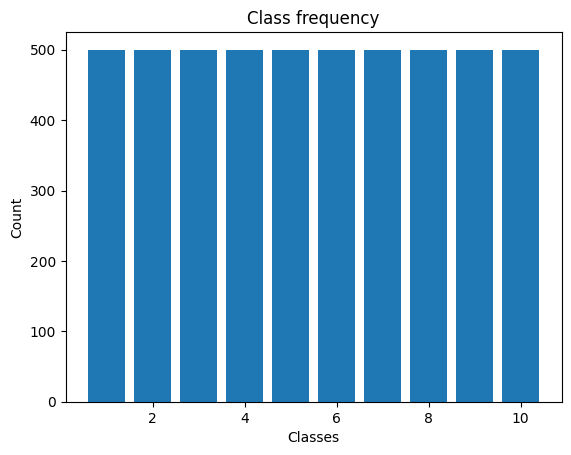

In [5]:
unique, count = np.unique(y, return_counts=True)
print(unique)
print(count)

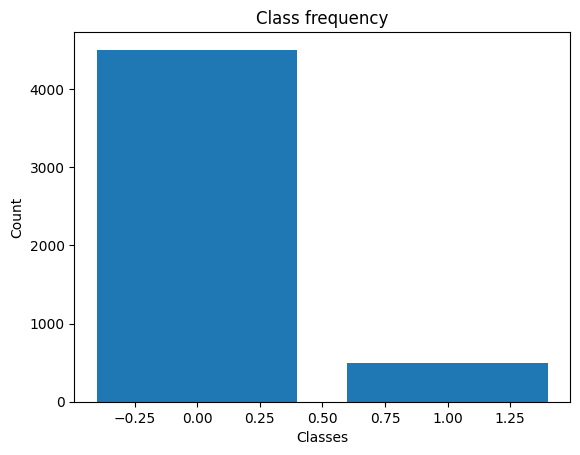

In [6]:
y = np.where(y == 3, 1, 0)
print_dataset(x, y)

unique, count = np.unique(y, return_counts=True)
print(unique)
print(count)

In [7]:
unique, count = np.unique(y, return_counts=True)
print(unique)
print(count)

[0 1]
[4500  500]


In [8]:
permutation = np.random.permutation(x.shape[0])
x = x[permutation]
y = y[permutation]

In [9]:
training_percentage = 0.8
training_size = int(x.shape[0] * training_percentage)

x_train = x[:training_size]
x_test = x[training_size:]
y_train = y[:training_size]
y_test = y[training_size:]

print(f"Training size = {x_train.shape[0]}")
print(f"Testing size = {x_test.shape[0]}")

Training size = 4000
Testing size = 1000


In [10]:
unique, count = np.unique(y_train, return_counts=True)
print(unique)
print(count)

[0 1]
[3604  396]


In [11]:
def apply_noise(x: np.ndarray, mean: float, std: float) -> np.ndarray:
    return x + np.random.normal(mean, std, x.shape) * np.where(x != 0, x, 0)

In [12]:
x_train = np.concatenate((x_train, apply_noise(x_train, 0.0, 0.1)))
y_train = np.concatenate((y_train, y_train))

In [13]:
unique, count = np.unique(y_train, return_counts=True)
print(unique)
print(count)

[0 1]
[7208  792]


In [14]:
model = keras.Sequential([
    layers.Input(shape=(x.shape[1],)),
    layers.Dense(100, activation='relu'),
    layers.Dense(100, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,301 (196.49 KB)

 Trainable params: 50,301 (196.49 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
batch_size = 800
epochs = 100

model.compile(loss="mean_squared_error", metrics=["accuracy", "precision", "recall", tf.keras.metrics.F1Score(threshold=0.5)])

training_history=model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, shuffle=True, validation_split=0.2, verbose=0)

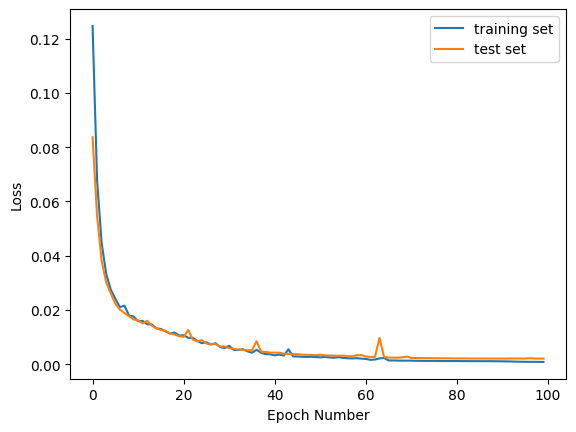

In [16]:
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.plot(training_history.history['loss'], label='training set')
plt.plot(training_history.history['val_loss'], label='test set')
plt.legend()

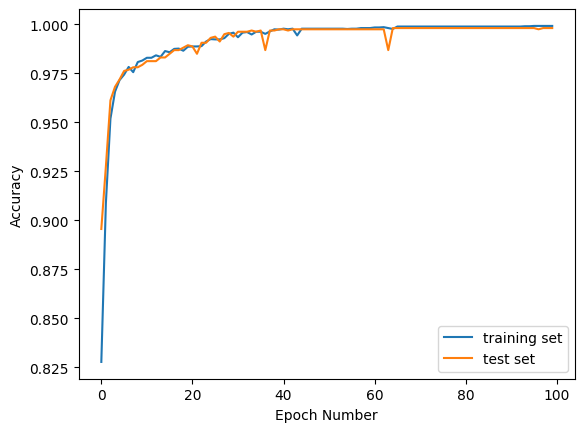

In [17]:
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.plot(training_history.history['accuracy'], label='training set')
plt.plot(training_history.history['val_accuracy'], label='test set')
plt.legend()

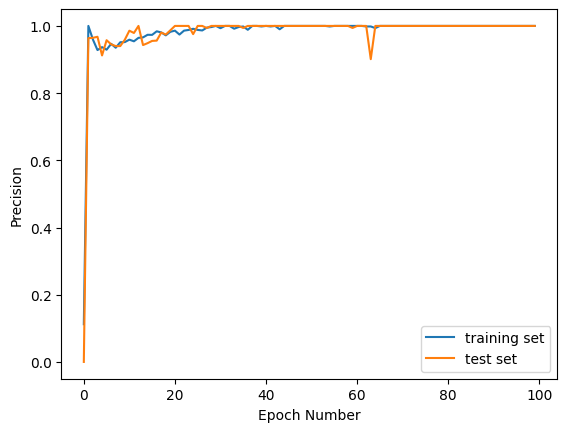

In [18]:
plt.xlabel('Epoch Number')
plt.ylabel('Precision')
plt.plot(training_history.history['precision'], label='training set')
plt.plot(training_history.history['val_precision'], label='test set')
plt.legend()

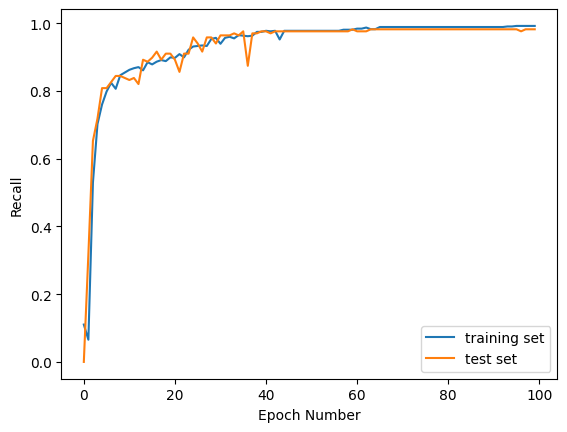

In [19]:
plt.xlabel('Epoch Number')
plt.ylabel('Recall')
plt.plot(training_history.history['recall'], label='training set')
plt.plot(training_history.history['val_recall'], label='test set')
plt.legend()

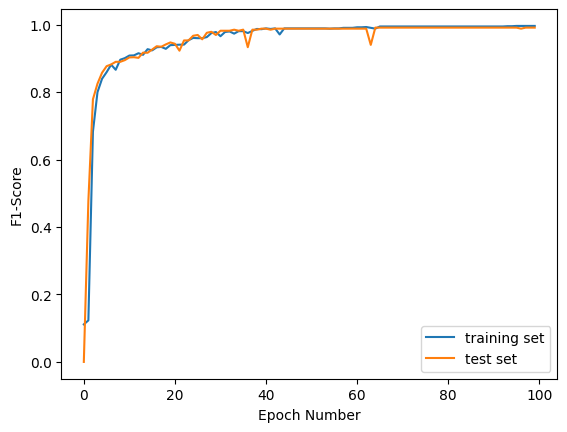

In [20]:
plt.xlabel('Epoch Number')
plt.ylabel('F1-Score')
plt.plot(training_history.history['f1_score'], label='training set')
plt.plot(training_history.history['val_f1_score'], label='test set')
plt.legend()

In [21]:
score = model.evaluate(x_train, y_train)
print("Train loss:", score[0])
print("Train accuracy:", score[1])
print("Train precision:", score[2])
print("Train recall:", score[3])
print("Train f1-score:", score[4])

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step - accuracy: 0.9990 - f1_score: 0.9949 - loss: 0.0011 - precision: 1.0000 - recall: 0.9899    
Train loss: 0.0011446395656093955
Train accuracy: 0.9990000128746033
Train precision: 1.0
Train recall: 0.9898989796638489
Train f1-score: [0.99492383]


In [22]:
score = model.evaluate(x_test, y_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])
print("Test precision:", score[2])
print("Test recall:", score[3])
print("Test f1-score:", score[4])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 456us/step - accuracy: 0.9840 - f1_score: 0.9216 - loss: 0.0121 - precision: 0.9400 - recall: 0.9038
Test loss: 0.012050599791109562
Test accuracy: 0.984000027179718
Test precision: 0.9399999976158142
Test recall: 0.9038461446762085
Test f1-score: [0.92156863]


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step


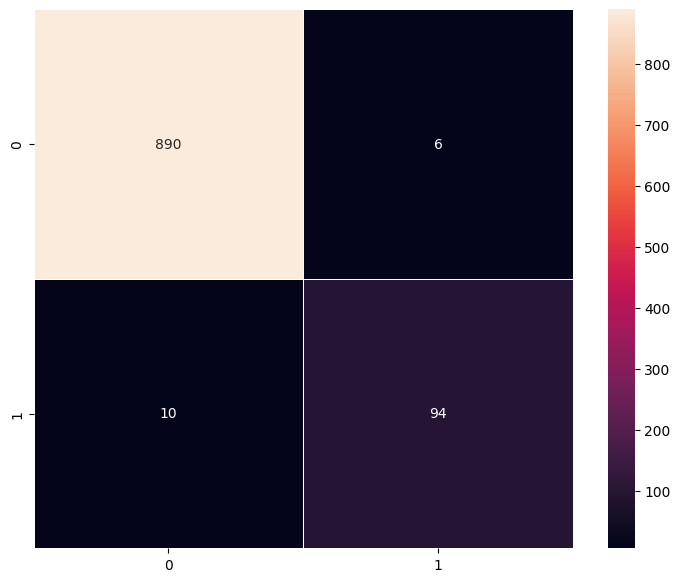

In [23]:
confusion_matrix = tf.math.confusion_matrix(y_test.T[0], np.round(model.predict(x_test).T[0]))
f, ax = plt.subplots(figsize=(9, 7))
sn.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.5,
    fmt="d",
    square=True,
    ax=ax
)
plt.show()